<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/00_AED_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB00 — Análise Exploratória de Dados (AED)

## 1. Contexto

Este notebook reúne a análise exploratória de dados do pipeline, com foco em caracterizar a base temporal, os episódios críticos, os estados operacionais e a estrutura inicial do problema de transição.

Sua função é separar a etapa de exploração e entendimento dos dados da etapa de modelagem supervisionada, permitindo maior clareza metodológica na dissertação e no artigo.

## 2. Objetivo

Os objetivos deste notebook são:

- caracterizar os artefatos principais já produzidos pelo pipeline;
- descrever a distribuição temporal dos eventos e falhas;
- analisar a métrica `fail_rate` e sua relação com a criticidade;
- examinar os episódios críticos detectados;
- explorar a distribuição dos estados operacionais;
- inspecionar a base de transição construída no NB06;
- gerar gráficos e tabelas descritivas úteis para o artigo e para a dissertação.

## 3. Papel no Pipeline Atualizado

Este notebook não altera os artefatos do pipeline principal.

Seu papel é:

- fornecer evidência exploratória e interpretativa para o trabalho;
- apoiar a justificativa metodológica das escolhas feitas nos notebooks NB04, NB05 e NB06;
- consolidar a AED como etapa própria, anterior à modelagem do NB08 e à consolidação do NB09.

## 4. Artefatos Utilizados

Este notebook utiliza, quando disponíveis:

- `google_trace_clean.parquet`
- `window_5min_series.parquet`
- `episodes_detected.parquet`
- `window_5min_features.parquet`
- `window_5min_labeled.parquet`
- `transition_dataset.parquet`

## 5. Eixos da Análise

A análise exploratória será organizada em cinco eixos:

1. visão geral dos dados e dos artefatos;
2. comportamento temporal da série agregada;
3. distribuição da taxa de falha e dos episódios críticos;
4. estados operacionais e transições;
5. estrutura inicial do problema supervisionado de transição.

## 6. Relação com as Próximas Etapas

Os achados deste notebook ajudam a sustentar:

- a definição de criticidade por taxa no NB04;
- a engenharia de atributos do NB05;
- a formulação supervisionada do NB06;
- a modelagem comparativa do NB08;
- a consolidação do artigo no NB09.

## 7. Observações Metodológicas

- este notebook tem caráter descritivo e interpretativo;
- ele não substitui os notebooks de processamento;
- sua função principal é melhorar a legibilidade científica do trabalho;
- sempre que possível, as análises são feitas com base nos artefatos já persistidos pelo pipeline.

Mounted at /content/drive
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/02-processed/google_trace_clean.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_series.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/episodes_detected.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_features.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/window_5min_labeled.parquet
[NB00_AED] Lendo: /content/drive/MyDrive/Mestrado/02-datasets/03-features/transition_dataset.parquet

===== google_trace_clean =====
shape: (349151, 23)
columns: ['time', 'collection_id', 'scheduling_class', 'priority', 'instance_index', 'machine_id', 'resource_request', 'scheduler', 'start_time', 'end_time', 'average_usage', 'maximum_usage', 'random_sample_usage', 'assigned_memory', 'page_cache_memory', 'cycles_per_instruction', 'memory_accesses_per_instruction

,time,collection_id,scheduling_class,priority,instance_index,machine_id,resource_request,scheduler,start_time,end_time,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,event,failed,t_rel_us,hour
0,2517305308183,260697606809,2,360,335,85515092,"{'cpus': 0.00724029541015625, 'memory': 0.0013...",0.0,1800713000000,1800714000000,...,0.000000,0.000000,NaN,NaN,1.0,7,FAIL,1,2517305308183,699
1,195684022913,276227177776,2,103,376,169321752432,"{'cpus': 0.048583984375, 'memory': 0.004165649...",1.0,81300000000,81600000000,...,0.010422,0.000235,0.939919,0.001318,1.0,7,SCHEDULE,0,195684022913,54
2,1810627494172,25911621841,2,0,3907,231364893292,"{'cpus': 0.00244903564453125, 'memory': 0.0002...",0.0,1565315000000,1565317000000,...,0.000272,0.000010,NaN,NaN,1.0,2,FINISH,0,1810627494172,502
3,1626744497194,235085571060,0,103,345,34202965855,"{'cpus': 0.0615234375, 'memory': 0.00540924072...",1.0,1626600000000,1626761000000,...,0.005409,0.001844,NaN,NaN,1.0,5,SCHEDULE,0,1626744497194,451
4,130721370174,275444626052,1,117,13138,10129440520,"{'cpus': 0.00566864013671875, 'memory': 0.0015...",0.0,343800000000,344100000000,...,0.002190,0.000006,0.646689,0.007937,1.0,7,ENABLE,0,130721370174,36



===== window_5min_series =====
shape: (8918, 18)
columns: ['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count']


,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,req_mem_presence_rate,event_FAIL_count,event_SCHEDULE_count,event_FINISH_count,event_ENABLE_count,event_LOST_count,event_EVICT_count,event_KILL_count
0,12,3600000000,25,6,25,20,270.160000,0.019362,0.020901,1.0,1.0,6,2,2,4,11,0,0
1,13,3900000000,46,13,43,23,209.717391,0.007103,0.018461,1.0,1.0,13,0,13,7,12,0,1
2,14,4200000000,34,11,32,20,189.382353,0.014036,0.015593,1.0,1.0,11,1,10,7,5,0,0
3,15,4500000000,44,10,41,29,249.522727,0.008850,0.003220,1.0,1.0,10,0,9,10,15,0,0
4,16,4800000000,22,5,22,19,219.045455,0.011749,0.003593,1.0,1.0,5,1,6,4,5,0,1



===== episodes_detected =====
shape: (285, 13)
columns: ['episode_id', 'start_bucket', 'end_bucket', 'duration_windows', 'duration_minutes', 'max_fail_rate', 'mean_fail_rate', 'max_failed', 'mean_failed', 'sum_failed', 'threshold', 'mu', 'sigma']


...


===== transition_dataset =====
shape: (6808, 41)
columns: ['bucket_id', 'bucket_start_us', 'n_events', 'n_failed', 'n_machines', 'n_collections', 'mean_priority', 'mean_req_cpus', 'mean_req_mem', 'req_cpus_presence_rate', 'req_mem_presence_rate', 'event_FAIL_count', 'event_SCHEDULE_count', 'event_FINISH_count', 'event_ENABLE_count', 'event_LOST_count', 'event_EVICT_count', 'event_KILL_count', 'fail_rate', 'is_critical', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_1h', 'rolling_std_1h', 'pct_change', 'zscore_global', 'state', 'next_bucket_id', 'next_state', 'is_last_window', 'has_valid_next', 'transition', 'future_horizon_valid', 'future_has_during', 'future_all_normal', 'future_path_states', 'future_first_during_offset', 'transition_target', 'transition_label', 'prediction_horizon_minutes']


,bucket_id,bucket_start_us,n_events,n_failed,n_machines,n_collections,mean_priority,mean_req_cpus,mean_req_mem,req_cpus_presence_rate,...,has_valid_next,transition,future_horizon_valid,future_has_during,future_all_normal,future_path_states,future_first_during_offset,transition_target,transition_label,prediction_horizon_minutes
0,15,4500000000,44,10,41,29,249.522727,0.008850,0.003220,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
1,16,4800000000,22,5,22,19,219.045455,0.011749,0.003593,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
2,17,5100000000,28,5,27,22,279.392857,0.010309,0.004613,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
3,18,5400000000,29,7,29,22,259.517241,0.007249,0.009697,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60
4,19,5700000000,36,9,34,27,237.027778,0.010176,0.009284,1.0,...,True,NORMAL->NORMAL,True,False,True,NORMAL | NORMAL | NORMAL | NORMAL | NORMAL | N...,NaN,0,STAYS_NORMAL_12_WINDOWS,60



[Resumo dos artefatos]


,artifact,rows,cols
0,google_trace_clean,349151,23
1,window_5min_series,8918,18
2,episodes_detected,285,13
3,window_5min_features,8914,27
4,window_5min_labeled,8914,38
5,transition_dataset,6808,41


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_01_n_events_por_janela.png


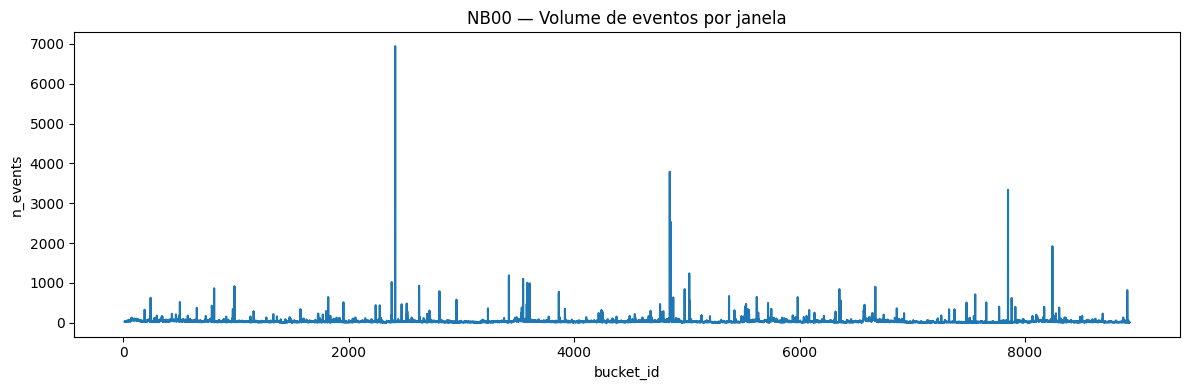

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_02_n_failed_por_janela.png


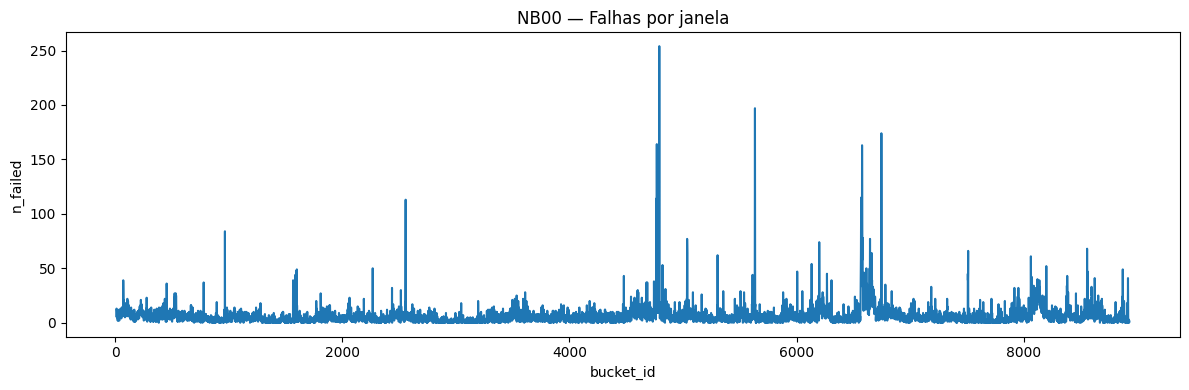

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_03_fail_rate_por_janela.png


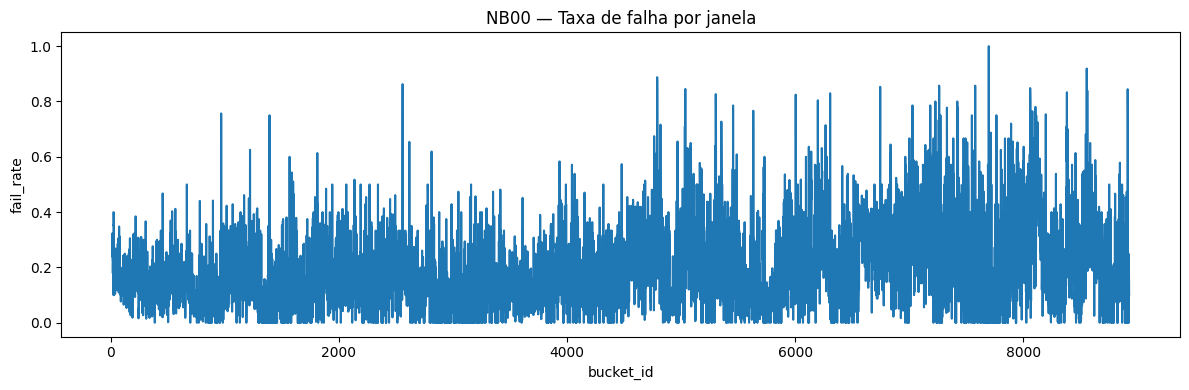

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_04_hist_fail_rate.png


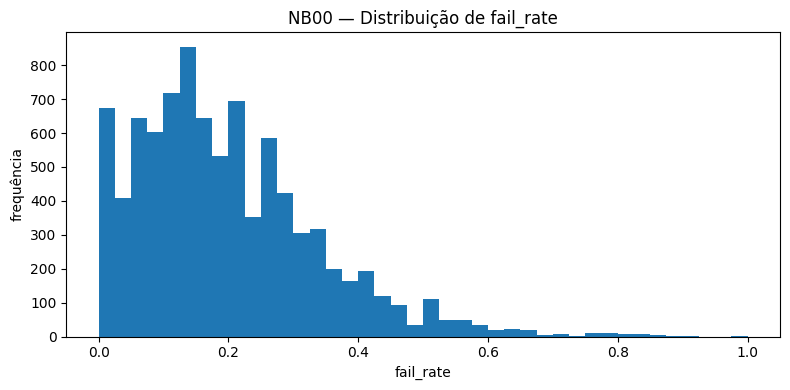


[Estatísticas de fail_rate]
mu = 0.19650583532910482
sigma = 0.14088360205396253
threshold_mu_2sigma = 0.47827303943702987
critical_windows = 389

[Resumo de episódios]


,episode_id,start_bucket,end_bucket,duration_windows,duration_minutes,max_fail_rate,mean_fail_rate,max_failed,mean_failed,sum_failed,threshold,mu,sigma
0,1,666,666,1,5,0.500000,0.500000,7,7.0,7,0.478258,0.196506,0.140876
1,2,967,967,1,5,0.756757,0.756757,84,84.0,84,0.478258,0.196506,0.140876
2,3,1220,1220,1,5,0.625000,0.625000,10,10.0,10,0.478258,0.196506,0.140876
3,4,1391,1391,1,5,0.750000,0.750000,6,6.0,6,0.478258,0.196506,0.140876
4,5,1567,1567,1,5,0.600000,0.600000,39,39.0,39,0.478258,0.196506,0.140876


,episodes_total,duration_windows_mean,duration_windows_median,duration_windows_max,duration_minutes_mean,duration_minutes_median,duration_minutes_max,max_fail_rate_mean,max_fail_rate_median,max_fail_rate_max,mean_fail_rate_mean,mean_fail_rate_median,mean_fail_rate_max
0,285,1.382456,1.0,7.0,6.912281,5.0,35.0,0.587748,0.555556,1.0,0.573985,0.545455,1.0


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_05_hist_duracao_episodios.png


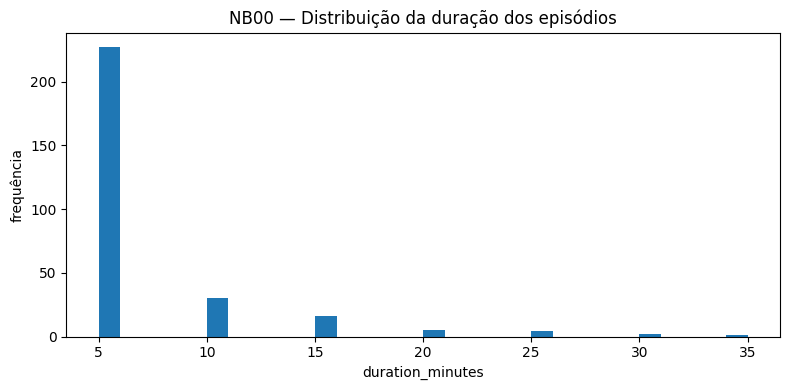

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_06_hist_max_fail_rate_episodios.png


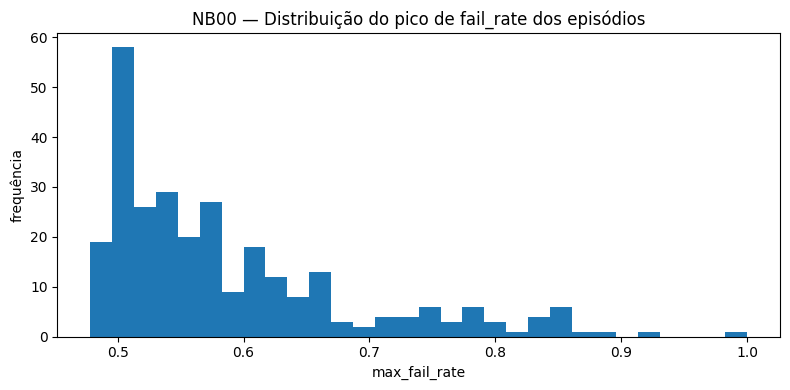


[Distribuição de estados]


,count
state,
NORMAL,5533
BEFORE,1996
AFTER,991
DURING,394


,proportion
state,
AFTER,0.111173
BEFORE,0.223917
DURING,0.044200
NORMAL,0.620709


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_07_distribuicao_estados.png


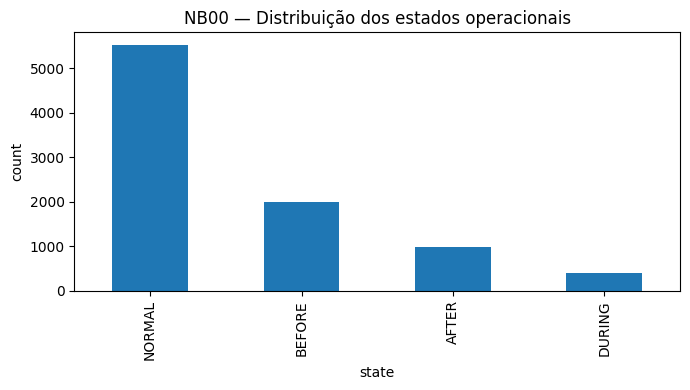


[Matriz de transição — contagens]


next_state,AFTER,BEFORE,DURING,NORMAL
state,,,,
AFTER,890,34,0,66
BEFORE,0,1711,285,0
DURING,101,184,109,0
NORMAL,0,67,0,5466



[Matriz de transição — proporções]


next_state,AFTER,BEFORE,DURING,NORMAL
state,,,,
AFTER,0.898990,0.034343,0.000000,0.066667
BEFORE,0.000000,0.857214,0.142786,0.000000
DURING,0.256345,0.467005,0.276650,0.000000
NORMAL,0.000000,0.012109,0.000000,0.987891


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_08_matriz_transicao_estados.png


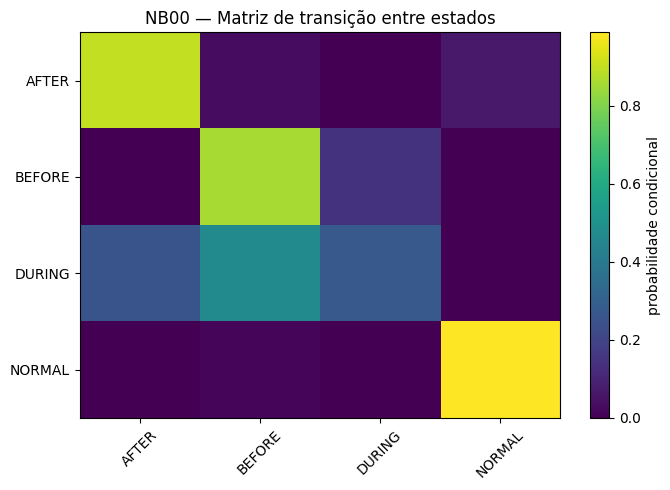


[Resumo do transition_dataset]
shape: (6808, 41)

[Distribuição do alvo]


,count
transition_target,
0,4812
1,1996


,proportion
transition_target,
0,0.706816
1,0.293184


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_09_distribuicao_transition_target.png


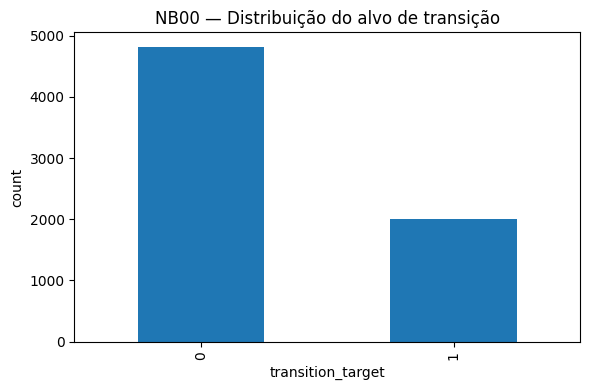


[Estado atual no transition_dataset]


,count
state,
NORMAL,4812
BEFORE,1996



[Média das features por classe]


transition_target,0,1
fail_rate,0.152609,0.230918
rolling_mean_1h,0.153191,0.254383
rolling_std_1h,0.083630,0.128591
zscore_global,-0.311596,0.244273


[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_fail_rate.png


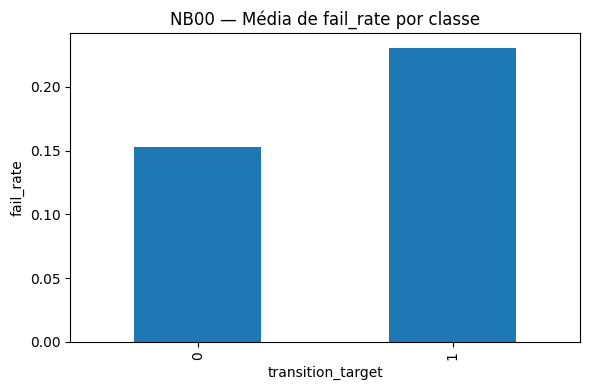

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_rolling_mean_1h.png


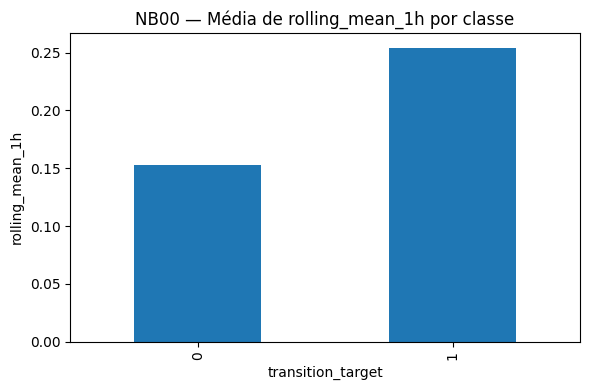

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_rolling_std_1h.png


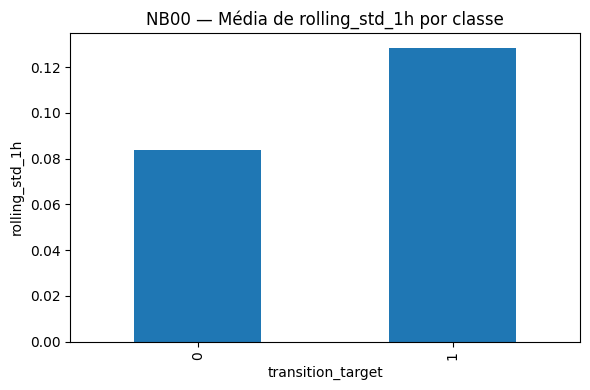

[NB00_AED] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/figures_nb00_aed/fig_feature_mean_zscore_global.png


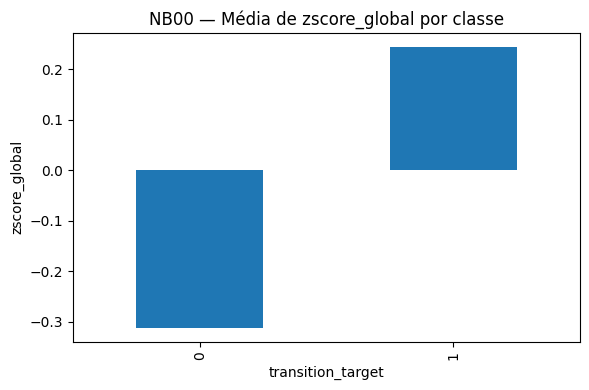

[NB00_AED] Resumo salvo: /content/drive/MyDrive/Mestrado/04-reports/00_aed_summary.json


In [1]:
# ============================================================
# NB00 — Análise Exploratória de Dados (AED)
# Pipeline PPCOMP_DM (Google Cluster Trace)
# ============================================================

# -----------------------------
# 0) BOOTSTRAP
# -----------------------------
from pathlib import Path
import os
import sys
import subprocess
import importlib
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

if not Path("/content/drive/MyDrive").exists():
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("[Bootstrap] Google Drive já montado.")

REPO_DIR = Path("/content/drive/MyDrive/Mestrado/PPCOMP_DM")
GITHUB_REPO = "https://github.com/sergiocostaifes/PPCOMP_DM.git"

if not REPO_DIR.exists():
    REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", GITHUB_REPO, str(REPO_DIR)], check=True)
else:
    try:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull"], check=True)
    except Exception as e:
        print("[Bootstrap] Aviso no git pull:", e)

os.chdir(str(REPO_DIR))
repo_str = str(REPO_DIR)
if repo_str not in sys.path:
    sys.path.insert(0, repo_str)

importlib.invalidate_caches()

from src.paths import PROCESSED_PATH, FEATURES_PATH, REPORTS_PATH, ensure_dirs

ensure_dirs()

def log(msg: str) -> None:
    print(f"[NB00_AED] {msg}")

# -----------------------------
# 1) INPUTS
# -----------------------------
CLEAN_FILE = PROCESSED_PATH / "google_trace_clean.parquet"
SERIES_FILE = FEATURES_PATH / "window_5min_series.parquet"
EPISODES_FILE = FEATURES_PATH / "episodes_detected.parquet"
FEATURES_FILE = FEATURES_PATH / "window_5min_features.parquet"
LABELED_FILE = FEATURES_PATH / "window_5min_labeled.parquet"
TRANSITION_FILE = FEATURES_PATH / "transition_dataset.parquet"

def safe_read_parquet(path: Path):
    if path.exists():
        log(f"Lendo: {path}")
        return pd.read_parquet(path)
    log(f"Arquivo não encontrado: {path}")
    return None

df_clean = safe_read_parquet(CLEAN_FILE)
df_series = safe_read_parquet(SERIES_FILE)
df_episodes = safe_read_parquet(EPISODES_FILE)
df_features = safe_read_parquet(FEATURES_FILE)
df_labeled = safe_read_parquet(LABELED_FILE)
df_transition = safe_read_parquet(TRANSITION_FILE)

# -----------------------------
# 2) FUNÇÕES AUXILIARES
# -----------------------------
FIG_DIR = REPORTS_PATH / "figures_nb00_aed"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_current_fig(name: str):
    out = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    log(f"Figura salva: {out}")

def show_basic_info(df: pd.DataFrame, name: str):
    if df is None:
        return
    print(f"\n===== {name} =====")
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head())

# -----------------------------
# 3) VISÃO GERAL DOS ARTEFATOS
# -----------------------------
show_basic_info(df_clean, "google_trace_clean")
show_basic_info(df_series, "window_5min_series")
show_basic_info(df_episodes, "episodes_detected")
show_basic_info(df_features, "window_5min_features")
show_basic_info(df_labeled, "window_5min_labeled")
show_basic_info(df_transition, "transition_dataset")

# -----------------------------
# 4) TABELA-SÍNTESE DOS ARTEFATOS
# -----------------------------
artifact_rows = []

for name, df in [
    ("google_trace_clean", df_clean),
    ("window_5min_series", df_series),
    ("episodes_detected", df_episodes),
    ("window_5min_features", df_features),
    ("window_5min_labeled", df_labeled),
    ("transition_dataset", df_transition),
]:
    if df is not None:
        artifact_rows.append({
            "artifact": name,
            "rows": int(df.shape[0]),
            "cols": int(df.shape[1]),
        })

artifacts_summary = pd.DataFrame(artifact_rows)
print("\n[Resumo dos artefatos]")
display(artifacts_summary)

# -----------------------------
# 5) ANÁLISE DA SÉRIE TEMPORAL
# -----------------------------
if df_series is not None:
    assert "bucket_id" in df_series.columns, "bucket_id ausente em window_5min_series"
    assert "n_events" in df_series.columns, "n_events ausente em window_5min_series"
    assert "n_failed" in df_series.columns, "n_failed ausente em window_5min_series"

    if "fail_rate" not in df_series.columns:
        df_series = df_series.copy()
        df_series["fail_rate"] = np.where(
            df_series["n_events"] > 0,
            df_series["n_failed"] / df_series["n_events"],
            0.0
        )

    # Figura 1 — n_events ao longo do tempo
    plt.figure(figsize=(12, 4))
    plt.plot(df_series["bucket_id"], df_series["n_events"])
    plt.xlabel("bucket_id")
    plt.ylabel("n_events")
    plt.title("NB00 — Volume de eventos por janela")
    save_current_fig("fig_01_n_events_por_janela.png")
    plt.show()

    # Figura 2 — n_failed ao longo do tempo
    plt.figure(figsize=(12, 4))
    plt.plot(df_series["bucket_id"], df_series["n_failed"])
    plt.xlabel("bucket_id")
    plt.ylabel("n_failed")
    plt.title("NB00 — Falhas por janela")
    save_current_fig("fig_02_n_failed_por_janela.png")
    plt.show()

    # Figura 3 — fail_rate ao longo do tempo
    plt.figure(figsize=(12, 4))
    plt.plot(df_series["bucket_id"], df_series["fail_rate"])
    plt.xlabel("bucket_id")
    plt.ylabel("fail_rate")
    plt.title("NB00 — Taxa de falha por janela")
    save_current_fig("fig_03_fail_rate_por_janela.png")
    plt.show()

    # Distribuição de fail_rate
    plt.figure(figsize=(8, 4))
    plt.hist(df_series["fail_rate"], bins=40)
    plt.xlabel("fail_rate")
    plt.ylabel("frequência")
    plt.title("NB00 — Distribuição de fail_rate")
    save_current_fig("fig_04_hist_fail_rate.png")
    plt.show()

    mu_fail_rate = float(df_series["fail_rate"].mean())
    sigma_fail_rate = float(df_series["fail_rate"].std())
    threshold_fail_rate = float(mu_fail_rate + 2 * sigma_fail_rate)

    print("\n[Estatísticas de fail_rate]")
    print("mu =", mu_fail_rate)
    print("sigma =", sigma_fail_rate)
    print("threshold_mu_2sigma =", threshold_fail_rate)

    critical_windows = int((df_series["fail_rate"] >= threshold_fail_rate).sum())
    print("critical_windows =", critical_windows)

# -----------------------------
# 6) ANÁLISE DOS EPISÓDIOS
# -----------------------------
if df_episodes is not None:
    print("\n[Resumo de episódios]")
    display(df_episodes.head())

    episode_summary = {
        "episodes_total": int(len(df_episodes)),
    }

    for col in ["duration_windows", "duration_minutes", "max_fail_rate", "mean_fail_rate"]:
        if col in df_episodes.columns:
            episode_summary[f"{col}_mean"] = float(df_episodes[col].mean())
            episode_summary[f"{col}_median"] = float(df_episodes[col].median())
            episode_summary[f"{col}_max"] = float(df_episodes[col].max())

    display(pd.DataFrame([episode_summary]))

    if "duration_minutes" in df_episodes.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(df_episodes["duration_minutes"], bins=30)
        plt.xlabel("duration_minutes")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição da duração dos episódios")
        save_current_fig("fig_05_hist_duracao_episodios.png")
        plt.show()

    if "max_fail_rate" in df_episodes.columns:
        plt.figure(figsize=(8, 4))
        plt.hist(df_episodes["max_fail_rate"], bins=30)
        plt.xlabel("max_fail_rate")
        plt.ylabel("frequência")
        plt.title("NB00 — Distribuição do pico de fail_rate dos episódios")
        save_current_fig("fig_06_hist_max_fail_rate_episodios.png")
        plt.show()

# -----------------------------
# 7) ANÁLISE DOS ESTADOS
# -----------------------------
if df_labeled is not None:
    assert "state" in df_labeled.columns, "state ausente em window_5min_labeled"

    state_counts = df_labeled["state"].value_counts()
    state_props = df_labeled["state"].value_counts(normalize=True).sort_index()

    print("\n[Distribuição de estados]")
    display(state_counts.to_frame("count"))
    display(state_props.to_frame("proportion"))

    plt.figure(figsize=(7, 4))
    state_counts.plot(kind="bar")
    plt.xlabel("state")
    plt.ylabel("count")
    plt.title("NB00 — Distribuição dos estados operacionais")
    save_current_fig("fig_07_distribuicao_estados.png")
    plt.show()

    if "next_state" in df_labeled.columns:
        transition_counts = (
            df_labeled.dropna(subset=["next_state"])
            .groupby(["state", "next_state"])
            .size()
            .unstack(fill_value=0)
        )

        print("\n[Matriz de transição — contagens]")
        display(transition_counts)

        transition_probs = transition_counts.div(
            transition_counts.sum(axis=1), axis=0
        )

        print("\n[Matriz de transição — proporções]")
        display(transition_probs)

        plt.figure(figsize=(7, 5))
        plt.imshow(transition_probs.values, aspect="auto")
        plt.xticks(range(len(transition_probs.columns)), transition_probs.columns, rotation=45)
        plt.yticks(range(len(transition_probs.index)), transition_probs.index)
        plt.colorbar(label="probabilidade condicional")
        plt.title("NB00 — Matriz de transição entre estados")
        save_current_fig("fig_08_matriz_transicao_estados.png")
        plt.show()

# -----------------------------
# 8) ANÁLISE DO DATASET DE TRANSIÇÃO
# -----------------------------
if df_transition is not None:
    print("\n[Resumo do transition_dataset]")
    print("shape:", df_transition.shape)

    if "transition_target" in df_transition.columns:
        target_counts = df_transition["transition_target"].value_counts().sort_index()
        target_props = df_transition["transition_target"].value_counts(normalize=True).sort_index()

        print("\n[Distribuição do alvo]")
        display(target_counts.to_frame("count"))
        display(target_props.to_frame("proportion"))

        plt.figure(figsize=(6, 4))
        target_counts.plot(kind="bar")
        plt.xlabel("transition_target")
        plt.ylabel("count")
        plt.title("NB00 — Distribuição do alvo de transição")
        save_current_fig("fig_09_distribuicao_transition_target.png")
        plt.show()

    if "state" in df_transition.columns:
        current_state_counts = df_transition["state"].value_counts()
        print("\n[Estado atual no transition_dataset]")
        display(current_state_counts.to_frame("count"))

    # comparação simples de features numéricas por classe
    candidate_features = [
        "fail_rate",
        "fail_rate_lag_1",
        "fail_rate_lag_2",
        "fail_rate_lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change_fail_rate",
        "zscore_global",
    ]

    available_features = [c for c in candidate_features if c in df_transition.columns]

    if "transition_target" in df_transition.columns and available_features:
        grouped_stats = (
            df_transition.groupby("transition_target")[available_features]
            .mean()
            .T
        )
        print("\n[Média das features por classe]")
        display(grouped_stats)

        # Figura 10 — médias por classe
        for feature in available_features:
            plt.figure(figsize=(6, 4))
            means = df_transition.groupby("transition_target")[feature].mean()
            means.plot(kind="bar")
            plt.xlabel("transition_target")
            plt.ylabel(feature)
            plt.title(f"NB00 — Média de {feature} por classe")
            fname = f"fig_feature_mean_{feature}.png".replace("/", "_")
            save_current_fig(fname)
            plt.show()

# -----------------------------
# 9) SUMMARY JSON
# -----------------------------
summary = {
    "artifacts_available": {
        "google_trace_clean": bool(df_clean is not None),
        "window_5min_series": bool(df_series is not None),
        "episodes_detected": bool(df_episodes is not None),
        "window_5min_features": bool(df_features is not None),
        "window_5min_labeled": bool(df_labeled is not None),
        "transition_dataset": bool(df_transition is not None),
    }
}

if df_series is not None and "fail_rate" in df_series.columns:
    summary["series"] = {
        "rows": int(len(df_series)),
        "mu_fail_rate": float(mu_fail_rate),
        "sigma_fail_rate": float(sigma_fail_rate),
        "threshold_mu_2sigma": float(threshold_fail_rate),
        "critical_windows": int(critical_windows),
    }

if df_episodes is not None:
    summary["episodes"] = {
        "rows": int(len(df_episodes)),
    }
    for col in ["duration_windows", "duration_minutes", "max_fail_rate", "mean_fail_rate"]:
        if col in df_episodes.columns:
            summary["episodes"][f"{col}_mean"] = float(df_episodes[col].mean())

if df_labeled is not None and "state" in df_labeled.columns:
    summary["labeled"] = {
        "rows": int(len(df_labeled)),
        "state_distribution": {
            str(k): int(v)
            for k, v in df_labeled["state"].value_counts().to_dict().items()
        }
    }

if df_transition is not None and "transition_target" in df_transition.columns:
    summary["transition_dataset"] = {
        "rows": int(len(df_transition)),
        "cols": int(df_transition.shape[1]),
        "target_distribution": {
            str(k): int(v)
            for k, v in df_transition["transition_target"].value_counts().sort_index().to_dict().items()
        }
    }

summary_file = REPORTS_PATH / "00_aed_summary.json"
summary_file.write_text(
    json.dumps(summary, indent=2, ensure_ascii=False),
    encoding="utf-8"
)
log(f"Resumo salvo: {summary_file}")

